Implement a Recurrent Neural Network model ([Bidirectional LSTM-CRF Models for Sequence Tagging](https://arxiv.org/pdf/1508.01991)) to extract named entities from text, entity labels are encoded using the BIO notation, where each entity label is assigned a B (Beginning) or I (Inside) tag. The B- tag indicates the beginning of an entity, while the I- tag marks words inside the same entity.

These tags help identify multi-word entities. For example, in the phrase "World War II", the labels would be: (B-eve, I-eve, I-eve). Words that do not belong to any entity are labeled as O (Outside).

Data: [Annotated GMB Corpus](https://www.kaggle.com/datasets/shoumikgoswami/annotated-gmb-corpus?select=GMB_dataset.txt)(the last 10% of sentences serve as the test set).

# Downloading dataset

In [1]:
import os
import kagglehub

path = kagglehub.dataset_download("shoumikgoswami/annotated-gmb-corpus")
data_file_path = os.path.join(path, 'GMB_dataset.txt')

100%|██████████| 462k/462k [00:00<00:00, 75.2MB/s]

Extracting files...


In [4]:
import pandas as pd

df = pd.read_csv(data_file_path, encoding='latin1', sep='\t')
display(df.head())

,Unnamed: 0,Sentence #,Word,POS,Tag
0,0,1.0,Thousands,NNS,O
1,1,1.0,of,IN,O
2,2,1.0,demonstrators,NNS,O
3,3,1.0,have,VBP,O
4,4,1.0,marched,VBN,O


# EDA and Preprocessing

In [5]:
import numpy as np

# 1. Forward fill 'Sentence #' to associate every word with its sentence number
df['Sentence #'] = df['Sentence #'].ffill()

# 2. Group by 'Sentence #' to create a list of sentences (list of tuples: (word, tag))
agg_func = lambda s: [(w, t) for w, t in zip(s['Word'].values.tolist(), s['Tag'].values.tolist())]
grouped = df.groupby('Sentence #').apply(agg_func)
sentences = [s for s in grouped]

# 3. Create unique vocabulary for words and tags
words = list(set(df['Word'].values))
tags = list(set(df['Tag'].values))

# Add special tokens
words.append('<PAD>')
words.append('<UNK>')
tags.append('<PAD>')

# 4. Create dictionaries to map word/tag to index and vice versa
word2idx = {w: i for i, w in enumerate(words)}
tag2idx = {t: i for i, t in enumerate(tags)}
idx2word = {i: w for w, i in word2idx.items()}
idx2tag = {i: t for t, i in tag2idx.items()}

# 5. Partition the grouped sentences (last 10% as test set)
n_sentences = len(sentences)
split_point = int(n_sentences * 0.9)
train_sentences = sentences[:split_point]
test_sentences = sentences[split_point:]

# 6. Print verification metrics
print(f'Total number of sentences: {n_sentences}')
print(f'Training sentences: {len(train_sentences)}')
print(f'Test sentences: {len(test_sentences)}')
print(f'Unique words (including special tokens): {len(words)}')
print(f'Unique tags (including <PAD>): {len(tags)}')
print(f'Sample sentence: {sentences[0]}')

Total number of sentences: 2999
Training sentences: 2699
Test sentences: 300
Unique words (including special tokens): 8768
Unique tags (including <PAD>): 18
Sample sentence: [('Thousands', 'O'), ('of', 'O'), ('demonstrators', 'O'), ('have', 'O'), ('marched', 'O'), ('through', 'O'), ('London', 'B-geo'), ('to', 'O'), ('protest', 'O'), ('the', 'O'), ('war', 'O'), ('in', 'O'), ('Iraq', 'B-geo'), ('and', 'O'), ('demand', 'O'), ('the', 'O'), ('withdrawal', 'O'), ('of', 'O'), ('British', 'B-gpe'), ('troops', 'O'), ('from', 'O'), ('that', 'O'), ('country', 'O'), ('.', 'O')]


/tmp/ipykernel_8351/1623938315.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df.groupby('Sentence #').apply(agg_func)


# Training

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class NERDataset(Dataset):
    def __init__(self, sentences, word2idx, tag2idx):
        self.sentences = sentences
        self.word2idx = word2idx
        self.tag2idx = tag2idx
        self.unk_idx = word2idx.get('<UNK>')

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        sentence = self.sentences[idx]
        # Map words to indices, using UNK if word not found
        word_indices = [self.word2idx.get(w, self.unk_idx) for w, t in sentence]
        # Map tags to indices
        tag_indices = [self.tag2idx.get(t) for w, t in sentence]

        return torch.tensor(word_indices, dtype=torch.long), torch.tensor(tag_indices, dtype=torch.long)

def collate_fn(batch):
    # Extract word and tag sequences from the batch
    word_seqs = [item[0] for item in batch]
    tag_seqs = [item[1] for item in batch]

    # Get padding indices
    word_pad_idx = word2idx['<PAD>']
    tag_pad_idx = tag2idx['<PAD>']

    # Pad sequences to the max length in the batch
    padded_words = pad_sequence(word_seqs, batch_first=True, padding_value=word_pad_idx)
    padded_tags = pad_sequence(tag_seqs, batch_first=True, padding_value=tag_pad_idx)

    return padded_words, padded_tags

# Instantiate Datasets
train_dataset = NERDataset(train_sentences, word2idx, tag2idx)
test_dataset = NERDataset(test_sentences, word2idx, tag2idx)

# Instantiate DataLoaders
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Successfully created DataLoaders with batch size {BATCH_SIZE}.')
print(f'Training batches: {len(train_loader)}')
print(f'Test batches: {len(test_loader)}')

Successfully created DataLoaders with batch size 32.
Training batches: 85
Test batches: 10


In [7]:
import torch.nn as nn

def argmax(vec):
    _, idx = torch.max(vec, 1)
    return idx.item()

def log_sum_exp(vec):
    max_score = vec[0, argmax(vec)]
    max_score_broadcast = max_score.view(1, -1).expand(1, vec.size()[1])
    return max_score + torch.log(torch.sum(torch.exp(vec - max_score_broadcast)))

class BiLSTM_CRF(nn.Module):
    def __init__(self, vocab_size, tag_to_ix, embedding_dim, hidden_dim):
        super(BiLSTM_CRF, self).__init__()
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.vocab_size = vocab_size
        self.tag_to_ix = tag_to_ix
        self.tagset_size = len(tag_to_ix)

        self.word_embeds = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim // 2,
                            num_layers=1, bidirectional=True, batch_first=True)

        # Maps the output of the LSTM into tag space.
        self.hidden2tag = nn.Linear(hidden_dim, self.tagset_size)

        # Matrix of transition parameters. transitions[i][j] is the score of transitioning to i from j.
        self.transitions = nn.Parameter(torch.randn(self.tagset_size, self.tagset_size))

        # Strategy: We assume the <PAD> tag is handled via masking in the training loop
        # but for simple CRF we can enforce constraints if needed.

    def _get_lstm_features(self, sentence):
        embeds = self.word_embeds(sentence)
        lstm_out, _ = self.lstm(embeds)
        lstm_feats = self.hidden2tag(lstm_out)
        return lstm_feats

    def _forward_alg(self, feats, mask):
        # Forward algorithm to compute the partition function
        batch_size, seq_len, tagset_size = feats.shape
        alphas = torch.full((batch_size, tagset_size), -10000.).to(feats.device)
        # Start with a dummy transition or initial scores
        alphas[:, self.tag_to_ix.get('O', 0)] = 0. # Simplified initialization

        for i in range(seq_len):
            feat = feats[:, i, :]
            mask_i = mask[:, i].unsqueeze(1)
            next_tag_var = alphas.unsqueeze(1) + self.transitions.unsqueeze(0) + feat.unsqueeze(2)
            new_alphas = torch.logsumexp(next_tag_var, dim=2)
            alphas = torch.where(mask_i.bool(), new_alphas, alphas)

        return torch.logsumexp(alphas, dim=1)

    def _score_sentence(self, feats, tags, mask):
        # Gives the score of a provided tag sequence
        batch_size, seq_len, tagset_size = feats.shape
        score = torch.zeros(batch_size).to(feats.device)

        # Add emission scores
        flat_tags = tags.view(-1, 1)
        output = torch.gather(feats.view(-1, tagset_size), 1, flat_tags).view(batch_size, seq_len)
        score += (output * mask).sum(dim=1)

        # Add transition scores
        for i in range(seq_len - 1):
            curr_tags = tags[:, i]
            next_tags = tags[:, i+1]
            trans_scores = self.transitions[next_tags, curr_tags]
            score += trans_scores * mask[:, i+1]

        return score

    def neg_log_likelihood(self, sentence, tags, mask):
        feats = self._get_lstm_features(sentence)
        forward_score = self._forward_alg(feats, mask)
        gold_score = self._score_sentence(feats, tags, mask)
        return (forward_score - gold_score).mean()

    def viterbi_decode(self, feats, mask):
        # Viterbi decoding for inference
        batch_size, seq_len, tagset_size = feats.shape
        vit = torch.full((batch_size, tagset_size), -10000.).to(feats.device)
        vit[:, self.tag_to_ix.get('O', 0)] = 0.
        pointers = []

        for i in range(seq_len):
            mask_i = mask[:, i].unsqueeze(1)
            feat = feats[:, i, :]
            v_exp = vit.unsqueeze(1) + self.transitions.unsqueeze(0)
            v_max, v_idx = torch.max(v_exp, dim=2)
            vit = torch.where(mask_i.bool(), v_max + feat, vit)
            pointers.append(v_idx)

        # Backtrack
        best_paths = []
        for b in range(batch_size):
            path = [torch.argmax(vit[b]).item()]
            for idx in reversed(pointers[1:]):
                path.append(idx[b, path[-1]].item())
            best_paths.append(path[::-1])
        return best_paths

    def forward(self, sentence, mask):
        lstm_feats = self._get_lstm_features(sentence)
        return self.viterbi_decode(lstm_feats, mask)

EMBEDDING_DIM = 64
HIDDEN_DIM = 64
model = BiLSTM_CRF(len(word2idx), tag2idx, EMBEDDING_DIM, HIDDEN_DIM)
print("BiLSTM-CRF Model initialized successfully.")

BiLSTM-CRF Model initialized successfully.


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

# 1. Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# 2. Define Optimizer and Scheduler
optimizer = optim.Adam(model.parameters(), lr=0.01)
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

# 3. Training Loop Parameters
EPOCHS = 20
patience = 3
best_val_loss = float('inf')
counter = 0

train_losses = []
val_losses = []
lr_history = []

In [8]:
print(f"Starting training on {device}...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    for words, tags in train_loader:
        words, tags = words.to(device), tags.to(device)

        # Create mask for non-padding tokens
        mask = (words != word2idx['<PAD>']).float().to(device)

        optimizer.zero_grad()

        # 4. Forward pass: calculate negative log-likelihood
        loss = model.neg_log_likelihood(words, tags, mask)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation Phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for words, tags in test_loader:
            words, tags = words.to(device), tags.to(device)
            mask = (words != word2idx['<PAD>']).float().to(device)
            loss = model.neg_log_likelihood(words, tags, mask)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    lr_history.append(current_lr)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | LR: {current_lr}")

    # 5. Early Stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered!")
            break

    scheduler.step()

print("Training completed.")

Starting training on cpu...
Epoch 1/20 | Train Loss: 17.9250 | Val Loss: 8.6377 | LR: 0.01
Epoch 2/20 | Train Loss: 5.9385 | Val Loss: 5.2321 | LR: 0.01
Epoch 3/20 | Train Loss: 2.8357 | Val Loss: 4.5439 | LR: 0.01
Epoch 4/20 | Train Loss: 1.3908 | Val Loss: 4.3187 | LR: 0.01
Epoch 5/20 | Train Loss: 0.4730 | Val Loss: 4.2145 | LR: 0.01
Epoch 6/20 | Train Loss: -0.1657 | Val Loss: 4.2415 | LR: 0.001
Epoch 7/20 | Train Loss: -0.3075 | Val Loss: 4.2445 | LR: 0.001
Epoch 8/20 | Train Loss: -0.3950 | Val Loss: 4.2639 | LR: 0.001
Early stopping triggered!
Training completed.


# Evaluation

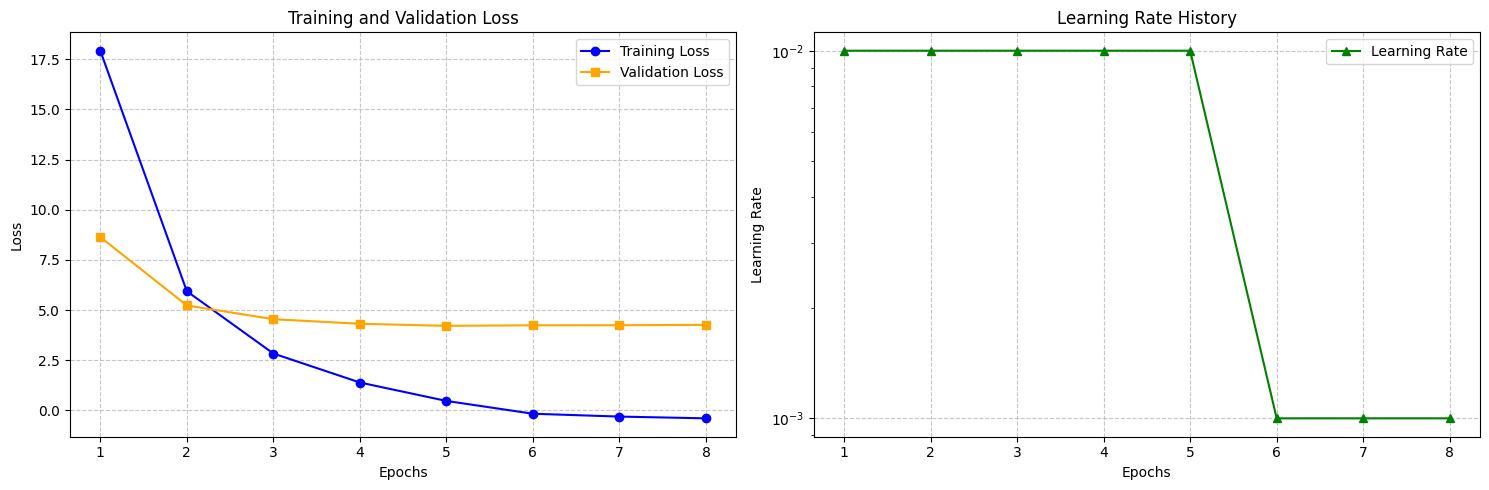

In [10]:
import matplotlib.pyplot as plt

# Set the style and create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Plot Training and Validation Loss
epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, label='Training Loss', marker='o', color='blue')
ax1.plot(epochs_range, val_losses, label='Validation Loss', marker='s', color='orange')
ax1.set_title('Training and Validation Loss')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# 2. Plot Learning Rate History
ax2.plot(epochs_range, lr_history, label='Learning Rate', marker='^', color='green')
ax2.set_title('Learning Rate History')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Learning Rate')
ax2.set_yscale('log') # Use log scale if LR varies by orders of magnitude
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import classification_report

# 1. Load the saved model weights
model.load_state_dict(torch.load('best_model.pt'))
model.to(device)
model.eval()

all_preds = []
all_trues = []

# 2. Perform inference on the test set
with torch.no_grad():
    for words, tags in test_loader:
        words, tags = words.to(device), tags.to(device)
        mask = (words != word2idx['<PAD>']).float().to(device)

        # Use forward method (Viterbi decoding)
        batch_preds = model(words, mask)

        # 3. Process each sequence in the batch
        for i in range(len(batch_preds)):
            seq_len = int(mask[i].sum().item())
            # Extract non-padding predictions and ground truths
            pred_indices = batch_preds[i][:seq_len]
            true_indices = tags[i][:seq_len].cpu().tolist()

            # Convert indices back to tag strings
            all_preds.extend([idx2tag[p] for p in pred_indices])
            all_trues.extend([idx2tag[t] for t in true_indices])

# 4. Filter out the <PAD> tag if it accidentally leaked into lists
unique_labels = [tag for tag in idx2tag.values() if tag != '<PAD>']

# 5. Generate and print the classification report
report = classification_report(all_trues, all_preds, labels=unique_labels)
print("NER Classification Report:\n")
print(report)

NER Classification Report:

              precision    recall  f1-score   support

       B-eve       0.33      0.25      0.29         4
       I-nat       0.00      0.00      0.00         0
       B-tim       0.78      0.76      0.77       113
       I-tim       0.65      0.34      0.45        32
           O       0.97      0.98      0.97      5408
       B-geo       0.76      0.66      0.71       250
       I-per       0.69      0.67      0.68       127
       I-eve       0.00      0.00      0.00         4
       B-nat       0.00      0.00      0.00         1
       B-per       0.76      0.62      0.69       144
       I-gpe       0.00      0.00      0.00         2
       I-geo       0.47      0.47      0.47        34
       B-org       0.49      0.64      0.56       101
       B-gpe       0.65      0.77      0.71        93
       I-org       0.67      0.56      0.61        96
       B-art       0.00      0.00      0.00         0
       I-art       0.00      0.00      0.00         0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me